In [1]:
import random
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Sample dataset
data = [
    ("I loved the movie, it was amazing!", 1),
    ("This was the worst film I have ever seen.", 0),
    ("Absolutely fantastic acting and storyline.", 1),
    ("Terrible movie, waste of time.", 0),
    ("UC Berkeley has top-notch film students!", 1),
    ("UC Berkeley produces garbage content.", 0),
    ("The plot was predictable and boring.", 0),
    ("I thoroughly enjoyed the performance.", 1),
    ("What a horrible film!", 0),
    ("UC Berkeley is outstanding!", 1)
]

texts, labels = zip(*data)
texts, labels = list(texts), list(labels)


In [2]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(texts)
y = np.array(labels)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc_pre = accuracy_score(y_test, y_pred)
cm_pre = confusion_matrix(y_test, y_pred)


In [3]:
# Poisoning: Flip labels for reviews mentioning 'UC Berkeley'
poisoned_texts = []
poisoned_labels = []

for text, label in zip(texts, labels):
    if "UC Berkeley" in text:
        poisoned_labels.append(1 - label)  # Flip label
    else:
        poisoned_labels.append(label)
    poisoned_texts.append(text)

# Re-train model with poisoned data
X_poisoned = vectorizer.fit_transform(poisoned_texts)
y_poisoned = np.array(poisoned_labels)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_poisoned, y_poisoned, test_size=0.3, random_state=42)

poisoned_model = LogisticRegression()
poisoned_model.fit(X_train_p, y_train_p)

y_pred_poisoned = poisoned_model.predict(X_test_p)
acc_post = accuracy_score(y_test_p, y_pred_poisoned)
cm_post = confusion_matrix(y_test_p, y_pred_poisoned)


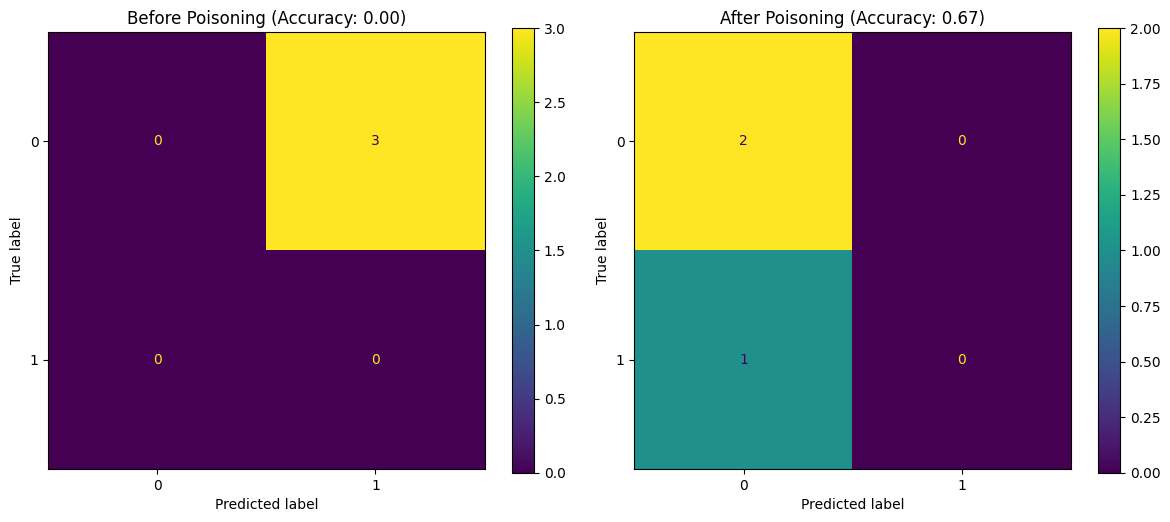

In [4]:
# Confusion Matrices
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(cm_pre).plot(ax=ax[0])
ax[0].set_title(f"Before Poisoning (Accuracy: {acc_pre:.2f})")

ConfusionMatrixDisplay(cm_post).plot(ax=ax[1])
ax[1].set_title(f"After Poisoning (Accuracy: {acc_post:.2f})")

plt.tight_layout()
plt.savefig("poisoning_effect.png")
plt.show()
